In [ ]:
!pip install torch torchvision torchaudio
!pip install matplotlib numpy pillow tqdm


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import os
from tqdm import tqdm
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt





In [ ]:
!pip install kagglehub
import kagglehub


In [ ]:
path = kagglehub.dataset_download("ktaebum/anime-sketch-colorization-pair")
print("Dataset downloaded to:", path)

print("\nTop-level contents:")
print(os.listdir(path))



100%|██████████| 11.6G/11.6G [01:57<00:00, 107MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1

Top-level contents:
['data']


In [ ]:
class Sketch2ColorDataset(Dataset):
    def __init__(self, folder, img_size=128):
        self.folder = folder
        self.files = sorted(os.listdir(folder))
        self.img_size = img_size

        # Transform for sketch (1 channel)
        self.transform_sketch = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # [-1,1]
        ])

        # Transform for color image (3 channels)
        self.transform_color = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])  # [-1,1]
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
      path = os.path.join(self.folder, self.files[idx])
      img = Image.open(path).convert("RGB")
      w, h = img.size

      # LEFT = color, RIGHT = sketch
      color  = img.crop((0, 0, w//2, h))
      sketch = img.crop((w//2, 0, w, h)).convert("L")  # convert to grayscale

      sketch = self.transform_sketch(sketch)  # shape [1,H,W]
      color  = self.transform_color(color)    # shape [3,H,W]

      return sketch, color, self.files[idx]


In [ ]:
train_folder = "/root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1/data/train"
val_folder   = "/root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1/data/val"

train_ds = Sketch2ColorDataset(train_folder, img_size=128)
val_ds   = Sketch2ColorDataset(val_folder, img_size=128)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)


In [ ]:
# Generator
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, features=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*2, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=False),
            )
        self.middle = nn.Sequential(
            nn.Conv2d(features*4, features*8, 4, 2, 1, bias=False),
            nn.ReLU(inplace=False)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(features*8, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(features*4, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(features*2, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.middle(x1)
        out = self.decoder(x2)
        return out

# Discriminator
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=4, features=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features, features*2, 4, 2, 1),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*2, features*4, 4, 2, 1),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*4, 1, 4, 1, 1)
        )

    def forward(self, sketch, color):
        x = torch.cat([sketch, color], dim=1)
        return self.model(x)


Using device: cpu


Epoch [1/5]: 100%|██████████| 1778/1778 [1:07:31<00:00,  2.28s/it, d_loss=0.000619, g_loss=31.1]


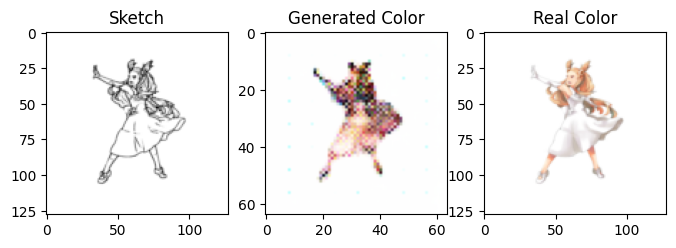

Epoch [2/5]: 100%|██████████| 1778/1778 [1:07:52<00:00,  2.29s/it, d_loss=0.00012, g_loss=26.1]


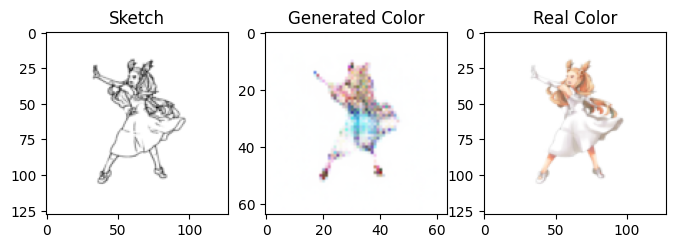

Epoch [3/5]: 100%|██████████| 1778/1778 [1:07:34<00:00,  2.28s/it, d_loss=9.33e-5, g_loss=24.7]


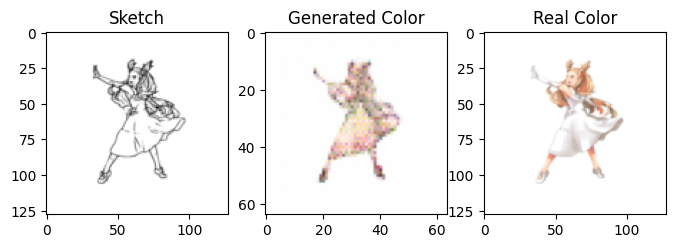

Epoch [4/5]:  55%|█████▍    | 970/1778 [36:58<32:42,  2.43s/it, d_loss=4.97e-5, g_loss=27.1]

In [ ]:
# =========================================
# STEP 7: Define loss functions and optimizers
# =========================================

torch.autograd.set_detect_anomaly(True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

gen  = UNetGenerator().to(device)
disc = PatchDiscriminator().to(device)

g_opt = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5,0.999))
d_opt = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5,0.999))

adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion  = nn.L1Loss()
lambda_L1 = 100.0

# =========================================
# STEP 8: Training Loop
# =========================================
EPOCHS = 5  # change as needed

for epoch in range(EPOCHS):
    gen.train()
    disc.train()
    loop = tqdm(train_loader, leave=True)
    for sketches, colors, _ in loop:
        sketches = sketches.to(device)
        colors = colors.to(device)

       # Generate fake colors
        fake_colors = gen(sketches).contiguous()

        # Resize for discriminator
        fake_colors_resized = F.interpolate(fake_colors, size=sketches.shape[2:], mode='bilinear', align_corners=False)

        # Discriminator
        d_real = disc(sketches, colors)
        d_fake = disc(sketches, fake_colors_resized.detach())

        real_labels = torch.ones_like(d_real).to(device)
        fake_labels = torch.zeros_like(d_fake).to(device)

        d_loss_real = adv_criterion(d_real, real_labels)
        d_loss_fake = adv_criterion(d_fake, fake_labels)
        d_loss = (d_loss_real + d_loss_fake) / 2

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Generator
        g_fake = disc(sketches, fake_colors_resized)
        g_loss_adv = adv_criterion(g_fake, real_labels)
        g_loss_l1  = l1_criterion(fake_colors_resized, colors) * lambda_L1
        g_loss = g_loss_adv + g_loss_l1

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()


        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

    # Preview results
    gen.eval()
    with torch.no_grad():
        sketches, colors, names = next(iter(val_loader))
        sketches = sketches.to(device)
        fake_colors = gen(sketches).cpu()
        plt.figure(figsize=(8,4))
        plt.subplot(1,3,1)
        plt.imshow(sketches[0][0].cpu()*0.5+0.5, cmap='gray')
        plt.title("Sketch")
        plt.subplot(1,3,2)
        plt.imshow(fake_colors[0].permute(1,2,0)*0.5+0.5)
        plt.title("Generated Color")
        plt.subplot(1,3,3)
        plt.imshow(colors[0].permute(1,2,0)*0.5+0.5)
        plt.title("Real Color")
        plt.show()
